In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
class MABM(object):
    """ 
    Introduction:
    - This is a class to simulate the work of multi_arm bandit machine. Given the necessary parameters, 
      the class could simulate the Discrete Markov Chain happens in the machine.
    
    Input:
    - arm_num: a scalar indicating the number of arms for the machine(or the number of total channels)
    - state_num: a scalar indicating the number of state for each arm(channel)(, given that they are all the same)
    - initial_dist: a matrix with dimension (arm_num, state_num), each row of which shows the initial distribution
      of each arm(channel)
    - transition_matrics: a tensor with dimension (arm_num, state_num, state_num), each matrix of which shows
      the transition matrix of each arm(channel)
    """
    
    def __init__(self, arm_num, state_num, initial_dist, transition_matrics):
        """
        Parameters:
        - N: a scalar for arm_numm
        - M: a scalar for state_num
        - W: an (N, M) marix, each row of which shows the current transition probablity of each arm(channel)
        - P: an (N, M, M) tensor, each matrix of which shows the transition matrix of each arm(channel)
        - state: an (N,) array showing the current state of each arm(channel)
        """
        self.tran_prob = initial_dist.copy()
        self.N = arm_num
        self.P = transition_matrics.copy()
        self.M = state_num
        self.state = np.zeros(self.N)
    
    
    def state_update(self):
        """
        Function:
        - Upadte the state of each arm(channel) according to the transition of Markov Chain.
        """
        for n in range(self.N):
            self.state[n] = np.random.choice(a = self.M, size = 1, p = self.tran_prob[n])
        self.state = self.state.astype(int)
    
    def transition_prob_update(self):
        """
        Function:
        - Update the current transition probability for each arm(channel) according to the current states of them.
        """
        self.tran_prob = self.P[(range(self.N),self.state)]
    
    def MABM_update(self):
        """
        Function:
        - Operate the machine once using the above functions.
        """
        self.state_update()
        #print(self.state)
        self.transition_prob_update()
        #print(self.W)
    

In [6]:
class Finite_Optimal_User(object):
    """
    Input:
    - MABM part:
      - arm_num: a scalar indicating the number of arms for the machine(or the number of total channels)
      - state_num: a scalar indicating the number of state for each arm(channel)(, given that they are all the same)
      - initial_dist: a matrix with dimension (arm_num, state_num), each row of which shows the initial distribution of each arm(channel)
      - transition_matrics: a tensor with dimension (arm_num, state_num, state_num), each matrix of which shows the transition matrix of each arm(channel)
    
    - Game Rule part:
      - active_num: a scalar indicating the number of active arms(channels)(, that is the arms user could observe)
      - reward_set: an matrix with dimension (arm_num, state_num) showing the reward of each state for each arm(channel)
      - time: a scalar indicating the time user plays the game
    """
    def __init__(self, arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, time):
        """
        Parameters:
        - mabm: an object simulating the Multi_Arm Bandit Machine
        - action: an (N,) array showing the current action of each arm(channel)(active or passive)
        - N: a scalar for arm_num
        - K: a scalar for active_num
        - belief_vec: an (N, M) marix, each row of which shows the current belief vector of each arm(channel)
        - P: an (N, M, M) tensor for transition_matrics
        - R: an (N, M) matrix showing the reward of each state for each arm(channel)
        - T: a scalar for the playing time
        - AR: an (T,) array showing the actual reward of each time
        - tran_0: an (N,) array showing the transition probablity p_{01} of each arm(channel)
        - tran_1: an (N,) array showing the transition probablity p_{11} of each arm(channel)
        """
        self.mabm = MABM(arm_num, state_num, initial_dist, transition_matrics)
        self.action = np.zeros(arm_num)
        self.belief_vec = initial_dist.copy()
        self.N = arm_num
        self.K = active_num
        self.R = reward_set.copy()
        self.P = transition_matrics.copy()
        self.T = time
        self.AR = np.array([])
        self.tran_0 = transition_matrics[:, 0, 1].copy().reshape(self.N)
        self.tran_1 = transition_matrics[:, 1, 1].copy().reshape(self.N)
    
    def belief_vec_update(self):
        """
        Function:
        - Update the belief vector according to the action of each arm(channel).
        """
        self.belief_vec[self.action == 1] = self.mabm.tran_prob[self.action == 1]
        self.belief_vec[self.action == 0] = (self.belief_vec[self.action == 0].reshape((self.N - self.K, 1, self.mabm.M))@self.P[self.action == 0, :, :]).reshape((self.N - self.K, self.mabm.M))
            
    def dis_reward(self, belief, t, subsidy, beta):
        """
        Function:
        - Compute the maximum discounted reward over all arms(channels) according to the recursion algorithm.

        Input:
        - t: a scalar indicating which slot it is
        - subsidy: a scalar indicating the subsidy for passive arm(channel)
        - beta: a scalar indicating the discounted factor

        Output:
        - index for the arm (channel) with maximum discounted reward
        - maximum discounted reward
        """
        if t == self.T - 1:
            return np.argmax(belief*self.R[:, 1]), np.max(belief*self.R[:, 1])
        else:
            reward_all = np.zeros(self.N) + subsidy*(self.N - self.K)
            for n in range(self.N):
                w = belief.copy()
                w = w*self.tran_1 + (1 - w)*self.tran_0
                w1 = w.copy(); w1[n] = self.tran_1[n]
                w0 = w.copy(); w0[n] = self.tran_0[n]
                _, reward0 = self.dis_reward(w0, t + 1, subsidy, beta)
                _, reward1 = self.dis_reward(w1, t + 1, subsidy, beta)
                reward_all[n] = beta*(belief[n]*reward1 + (1 - belief[n])*reward0) + belief[n]*self.R[n, 1] 
            return np.argmax(reward_all), np.max(reward_all)

    def action_AR_update(self, t, subsidy, beta):
        """
        Function:
        - Find the active arms(channels) of each time according to the index of arm(channel) with maximum discounted reward.
        - Compute actual reward according to the action of each time.
        """
        self.action = np.zeros(self.N)
        n, _ = self.dis_reward(self.belief_vec[:, 1], t, subsidy, beta)
        self.action[n] = 1
        self.AR = np.append(self.AR, np.sum(self.R[self.action == 1, self.mabm.state[self.action == 1]]))
    
    def User_process(self, subsidy, beta):
        """
        Function:
        - Simulate the game process of a optimal user with above functions.
        """
        for t in range(self.T):
            self.mabm.MABM_update()
            #print(self.action)
            #self.dis_reward_update(t, subsidy, beta)
            self.action_AR_update(t, subsidy, beta)
            #print(self.action, "\n")
            self.belief_vec_update()

In [15]:
arm_num = 7
active_num = 1
state_num = 2
time = 6
reward_set = np.array([0.4998, 0.6668, 1.0000, 0.6296, 0.5830, 0.8334, 0.6668])
reward_set = np.array([np.zeros(7), reward_set]).T
transition_matrics = np.array([[[0.2, 0.8],[0.4, 0.6]],
                              [[0.4, 0.6], [0.6, 0.4]],
                              [[0.6, 0.4], [0.8, 0.2]],
                              [[0.1, 0.9], [0.8, 0.2]],
                              [[0.2, 0.8], [0.6, 0.4]],
                              [[0.4, 0.6], [0.9, 0.1]],
                              [[0.3, 0.7], [0.7, 0.3]]])
#initial_dist = transition_matrics[:, 0, 1]/(transition_matrics[:, 0, 1] + transition_matrics[:, 1, 0])
#initial_dist = np.array([1 - initial_dist, initial_dist]).T
initial_dist = np.array([[0.8, 0.2],
                         [0.6, 0.4],
                         [0.3, 0.7],
                         [0.5, 0.5],
                         [0.9, 0.1],
                         [0.6, 0.4],
                         [0.2, 0.8]])

In [8]:
AR_50 = np.zeros((50, 6))
AR_100 = np.zeros((100, 6))
AR_1000 = np.zeros((1000, 6))
AR_10000 = np.zeros((10000, 6))
AR_100000 = np.zeros((100000, 6))

In [15]:
for n in range(100000):
    #print(n)
    user = Finite_Optimal_User(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, 1)
    user.User_process(0, 1)
    #print(user.action)
    AR_100000[n, 0] = user.AR

In [16]:
#(AR_50.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/50
#(AR_100.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100
#(AR_1000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/529
#(AR_10000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/10000
(AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000

array([0.3340468 , 0.33335999, 0.33313106, 0.33301659, 0.33294791,
       0.33290212])

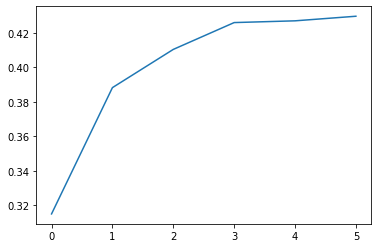

In [10]:
cum_AR_1000 = (AR_1000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/529
plt.plot(range(6), cum_AR_1000)

In [9]:
class Whittle_Index_two_state:
    """
    Introduction:
    - This is a class for the user of multi_arm bandit machine with 2 states(0 and 1), who uses the Whittle Index Policy. Given the necessary parameters for the machine and the rule of the game, the class could simulate the game process of the user in given time. 
      
    Input:
    - MABM part:
      - arm_num: a scalar indicating the number of arms for the machine(or the number of total channels)
      - state_num: a scalar indicating the number of state for each arm(channel)(, given that they are all 2 in this class)
      - initial_dist: a matrix with dimension (arm_num, state_num), each row of which shows the initial  distribution of each arm(channel)
      - transition_matrics: a tensor with dimension (arm_num, state_num, state_num), each matrix of which shows the transition matrix of each arm(channel)
    
    - Game Rule part:
      - active_num: a scalar indicating the number of active arms(channels)(, that is the arms user could observe)
      - reward_set: an matrix with dimension (arm_num, state_num) showing the reward of each state for each arm(channel)
      - time: a scalar indicating the time user plays the game
    """
    def __init__(self, arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, time):
        """
        Parameters:
        - mabm: an object simulating the Multi_Arm Bandit Machine
        - action: an (N,) array showing the current action of each arm(channel)(active or passive)
        - N: a scalar for arm_num
        - K: a scalar for active_num
        - belief_vec: an (N,) array showing the current belief state of each arm(channel)
        - tran_0: an (N,) array showing the transition probablity p_{01} of each arm(channel)
        - tran_1: an (N,) array showing the transition probablity p_{11} of each arm(channel)
        - stat_belief: an (N,) array showing the stationary belief state w_{0} of each arm(channel)
        - reward: an (N,) array showing the reward of good state for each arm(channel)
        - T: a scalar for the playing time
        - AR: an (T,) array showing the actual reward of each time
        """
        self.mabm = MABM(arm_num, state_num, initial_dist, transition_matrics)
        self.action = np.zeros(arm_num)
        self.belief_vec = initial_dist[:, 1].copy()
        self.N = arm_num
        self.K = active_num
        self.tran_0 = transition_matrics[:, 0, 1].copy().reshape(self.N)
        self.tran_1 = transition_matrics[:, 1, 1].copy().reshape(self.N)
        self.stat_belief = self.tran_0/(self.tran_0 + 1 - self.tran_1)
        self.reward = reward_set[:, 1].copy()
        self.T = time
        self.action = np.zeros(self.N)
        self.AR = np.array([])
    
    def belief_vec_update(self):
        """
        Function:
        - Update the belief vector according to the action of each arm(channel).
        """
        self.belief_vec[self.action == 1] = self.mabm.tran_prob[self.action == 1, 1]
        idx0 = (self.action == 0)
        self.belief_vec[idx0] = self.belief_vec[idx0]*self.tran_1[idx0] + (1 - self.belief_vec[idx0])*self.tran_0[idx0]

    def k_step_belief(self, k, belief, tran_0, tran_1):
        """
        Function:
        - Compute the k-step belief state.

        Input:
        - k: a scalar indicating whose belief state the function computes
        - belief: a scalar or an array indicating current belief state
        - tran_0: a scalar or an array showing the transition probablity p_{01}
        - tran_1: a scalar or an array showing the transition probablity p_{11}
        """
        temp = tran_1 - tran_0
        return (tran_0 - (temp**k)*(tran_0 - (1 -temp)*belief))/(1 - temp)

    def fir_cross_t(self, cur, tar, tran_0, tran_1, stat_belief):
        """
        Function:
        - Compute the first crossing time, from current belief state to target belief state, for positive correlated arm.

        Input:
        - cur: a scalar or an array showing the current belief state
        - tar: a scalar or an array showing the target belief state
        - stat_belief: a scalar or an array showing the stationary belief state w_{0}
        """
        L = np.zeros(np.size(cur))
        L[(cur <= tar)*(tar >= stat_belief)] = float('inf')
        temp_idx = (cur <= tar)*(tar < stat_belief)
        temp_val = 1 - tran_1[temp_idx] + tran_0[temp_idx]
        num = tran_0[temp_idx] - tar[temp_idx]*temp_val
        deno = tran_0[temp_idx] - cur[temp_idx]*temp_val
        L[temp_idx] = 1 + (np.log(num/deno)/np.log(1 - temp_val)).astype(int)
        #print(L)
        return L
    
    def whittle_idx_pos(self, w, beta, reward, tran_0, tran_1, stat_belief):
        """
        Function:
        - Compute the whittle index for positive correlated arm(channel)

        Input:
        - w: a scalar or an array showing the belief state for the whittle index
        - beta: a scalar indicating the discounted factor
        - reward: a scalar or an array showing the reward of good state
        """

        whittle_idx = np.zeros(np.size(w))

        idx1 = (w <= tran_0) + (w >= tran_1)
        idx2 = (stat_belief <= w)*(w < tran_1)
        idx3 = (tran_0 < w)*(w < stat_belief)

        L = self.fir_cross_t(tran_0[idx3], w[idx3], tran_0[idx3], tran_1[idx3], stat_belief[idx3])
        #print(L)
        T_L = self.k_step_belief(L, tran_0[idx3], tran_0[idx3], tran_1[idx3])
        beta_L = beta**(L + 1)
        temp1 = 1 - beta*tran_1[idx3]
        temp2 = temp1*(1 - beta_L) + (1 - beta)*beta_L*T_L
        C1 = temp1*(1 - beta_L/beta)/temp2
        C2 = T_L*(beta_L/beta)/temp2
        T_1 = self.k_step_belief(1, w[idx3], tran_0[idx3], tran_1[idx3])
        temp3 = w[idx3] - beta*T_1
        temp4 = beta*(temp1 - w[idx3] - temp3)

        whittle_idx[idx1] = w[idx1]*reward[idx1]
        whittle_idx[idx2] = (w[idx2]*reward[idx2])/(1 - beta*tran_1[idx2] + beta*w[idx2])
        whittle_idx[idx3] = reward[idx3]*(temp3 + C2*(1 - beta)*temp4)/(temp1 - C1*temp4)

        return whittle_idx

    def whittle_idx_neg(self, w, beta, reward, tran_0, tran_1, stat_belief):
        """
        Function:
        - Compute the whittle index for negative correlated arm(channel)
        """

        whittle_idx = np.zeros(np.size(w))
        
        T_p = self.k_step_belief(1, tran_1, tran_0, tran_1)
        idx1 = (w <= tran_1) + (w >= tran_0)
        idx2 = (T_p <= w)*(w < tran_0)
        idx3 = (stat_belief <= w)*(w < T_p)
        idx4 = (tran_1 < w)*(w < stat_belief)

        temp1_3 = 1 + (1 + beta)*beta*tran_0[idx3] - T_p[idx3]*(beta**2)
        temp1_4 = 1 + (1 + beta)*beta*tran_0[idx4] - T_p[idx4]*(beta**2)
        C3_3 = (1 - beta*(1 - tran_0[idx3]))/temp1_3
        C3_4 = (1 - beta*(1 - tran_0[idx4]))/temp1_4
        C4_3 = (beta*T_p[idx3]*(1 - beta) + tran_0[idx3]*(beta**2))/temp1_3
        C4_4 = (beta*T_p[idx4]*(1 - beta) + tran_0[idx4]*(beta**2))/temp1_4
        temp2 = beta*tran_0[idx3] + w[idx3]*(1 - beta)
        temp3_3 = 1 - beta*(1 - tran_0[idx3])
        temp3_4 = 1 - beta*(1 - tran_0[idx4])
        T_1 = self.k_step_belief(1, w[idx4], tran_0[idx4], tran_1[idx4])
        temp4 = beta*T_1 - beta*tran_0[idx4] - w[idx4]


        whittle_idx[idx1] = w[idx1]*reward[idx1]
        whittle_idx[idx2] = reward[idx2]*(beta*tran_0[idx2] + w[idx2]*(1 - beta))/(1 + beta*(tran_0[idx2] - w[idx2]))
        whittle_idx[idx3] = reward[idx3]*(1 - beta + beta*C4_3)*temp2/(temp3_3 - C3_3*beta*temp2)
        whittle_idx[idx4] = reward[idx4]*((beta - 1)*temp4 - C4_4*beta*temp4)/(temp3_4 + C3_4*beta*temp4)

        return whittle_idx

    

    
    def action_AR_update(self, beta):
        """
        Function:
        - Find the active arms(channels) of each time according to the whittle indices of them.
        - Compute actual reward according to the action of each time.
        """

        pos_arm = (self.tran_1 > self.tran_0)
        neg_arm = (self.tran_1 <= self.tran_0)
        m = np.zeros(self.N)
        m[pos_arm] = self.whittle_idx_pos(self.belief_vec[pos_arm], beta, self.reward[pos_arm], self.tran_0[pos_arm], self.tran_1[pos_arm], self.stat_belief[pos_arm])
        m[neg_arm] = self.whittle_idx_neg(self.belief_vec[neg_arm], beta, self.reward[neg_arm], self.tran_0[neg_arm], self.tran_1[neg_arm], self.stat_belief[neg_arm])

        self.action = np.zeros(self.N)
        self.action[m.argsort()[::-1][0:self.K]] = 1
        self.AR = np.append(self.AR, np.sum(self.reward[(self.action == 1)*(self.mabm.state== 1)]))
    
    def User_process(self, beta):
        """
        Function:
        - Simulate the game process of a user, who uses whittle index policy, with above functions.
        """
        
        for t in range(self.T):
            self.mabm.MABM_update()
            self.action_AR_update(beta)
            self.belief_vec_update()

In [43]:
class Whittle_Index_Three_State(object):
    """
    Introduction:
    - This is a class for the user of multi_arm bandit machine with 3 states(0, 1 and 2), who uses the Whittle Index Policy. Given the necessary parameters for the machine and the rule of the game, the class could simulate the game process of the user in given time. 
      
    Input:
    - MABM part:
      - arm_num: a scalar indicating the number of arms for the machine(or the number of total channels)
      - state_num: a scalar indicating the number of state for each arm(channel)(, given that they are all 2 in this class)
      - initial_dist: a matrix with dimension (arm_num, state_num), each row of which shows the initial  distribution of each arm(channel)
      - transition_matrics: a tensor with dimension (arm_num, state_num, state_num), each matrix of which shows the transition matrix of each arm(channel)
    
    - Game Rule part:
      - active_num: a scalar indicating the number of active arms(channels)(, that is the arms user could observe)
      - reward_set: an matrix with dimension (arm_num, state_num) showing the reward of each state for each arm(channel)
      - time: a scalar indicating the time user plays the game
    """
    def __init__(self, arm_num, state_num, initial_dist, stationary_dist, transition_matrics, active_num, reward_set, time):
        """
        Parameters:
        - mabm: an object simulating the Multi_Arm Bandit Machine
        - action: an (N,) array showing the current action of each arm(channel)(active or passive)
        - N: a scalar for arm_num
        - K: a scalar for active_num
        - M: a scalar for state_num
        - belief_vec: a (N,) array showing the current belief state of each arm(channel)
        - P: a (N, M, M) tensor, each matrix of which shows the transition matrix of each arm(channel)
        - reward: a (N, M) matrix showing the reward of each state for each arm(channel)
        - T: a scalar for the playing time
        - AR: an(T,) array showing the actual reward of each time
        - J: a (N, M) matrix, each row of which shows the eigenvalues of the transition matric of each arm (channel)
        - A: a (N, M, M) tensor, each matrix of which shows the eigenvectors of the transition matric of each arm (channel)
        - A_inv: a (N, M, M) tensor, each matrix of which shows the inverse of the each matrix of A
        - right_side: a (N, M) matrix, each row of which is the matrix product of each of A_inv and each row of reward(which is just the rightside term of J**k in k-step reward function) 
        - pos: a (M,) list, each element of which shows whether the mth(m=1,...,M) eigenvalue of each arm(channel) is one
        - b1: a (N,) array showing the base of the first exponential term in k-step reward function f(k), which is also one of the two eigenvalues(that are not equal to one) of each arm(channel) 
        - b2: a (N,) array showing the base of the second exponential term in k-step reward function f(k), which is also the other one of the two eigenvalues(that are not equal to one) of each arm(channel) 
        """
        self.mabm = MABM(arm_num, state_num, initial_dist, transition_matrics)
        self.P = transition_matrics.copy()
        self.action = np.zeros(arm_num)
        self.belief_vec = initial_dist.copy()
        self.M = state_num
        self.N = arm_num
        self.K = active_num
        self.reward = reward_set.copy()
        self.T = time
        self.action = np.zeros(self.N)
        self.AR = np.array([])
        self.w0 = stationary_dist.copy()
        self.tran_0 = transition_matrics[:, 0, 1].copy()
        self.tran_1 = transition_matrics[:, 1, 1].copy()
        self.A = np.zeros(np.shape(self.P))
        self.A_inv = np.zeros(np.shape(self.A))
        self.J = np.zeros((arm_num, 2))

    def matrics_decomposition(self, param):
            """
            Function:
            - Decompose the transition matrix of each arm(channel).
            - Set the parameters pos, b1 and b2 according to the position of eigenvalue of each arm(channel).
            - Compute the parameter right_side of the class.

            Input:
            - param: a (4,) list contains 4 parameters: set_decom, A, J, A_inv
                - set_decom: a boolean variable indicating that whether the matrics decomposition has been done
                - A:  if set_decom is True, a  (N, M, M) tensor, each matrix of which shows the eigenvectors of the transition matric of each arm (channel), or a empty list if set_decom is False
                - J: if set_decom is True, a (N, M) matrix, each row of which shows the eigenvalues of the transition matric of each arm (channel), or a empty list if set_decom is False
                - A_inv: if set_decom is True, a (N, M, M) tensor, each matrix of which shows the inverse of the each matrix of A, or a empty list if set_decom is False
            """
            set_decom, A, J, A_inv = param
            if set_decom:
                self.A = A.copy(); self.J = J.copy()
                self.A_inv = A_inv.copy()
            else:
                self.A, self.J = nplg.eig(self.P)
                self.A_inv = nplg.inv(self.A)
    

    def L_omega(self, omega, omega_star):
        """
        Function:
        - Compute the first crossing time of k-step reward function f(k).

        Input:
        - omega_star: a (N, M) matrix, each row of which shows the target belief state at which the k-step reward function want to arrive

        Output:
        - L: a (N,) array showing the first crossing time of each arm(channel)
        """
        L = np.zeros(self.N)
        w = omega[:, 1].copy()
        T_w = (omega.reshape((-1, 1, 2))@self.P.copy()).reshape(-1, 2)[:, 1].copy()
        w_star = omega_star[:, 1].copy()
        pos_pos = (self.tran_1 > self.tran_0); neg_pos = True^pos_pos
        if pos_pos.any():
            pos_case1 = pos_pos*(w > w_star)
            pos_case2 = pos_pos*(w <= w_star)*(w_star < self.stationary_dist[:, 1])
            pos_case3 = pos_pos*(w <= w_star)*(w_star >= self.stationary_dist[:, 1])

            if pos_case1.any():
                L[pos_case1] = 0

            if pos_case2.any():
                temp_val1 = 1 - self.tran_1[pos_case2] + self.tran_0[pos_case2]
                L[pos_case2] = np.int(np.log((self.tran_0[pos_case2] - w_star[pos_case2]*temp_val1)/(self.tran_0[pos_case2] - w[pos_case2]*temp_val1))/np.log(1 - temp_val1))

            if pos_case3.any():
                L[pos_case3] = np.inf
        if neg_pos.any():
            #print(T_w - w_star <= 1e-10)
            neg_case1 = neg_pos*(w - w_star > 1e-10)
            neg_case2 = neg_pos*(w_star - w >= 1e-10)*(T_w - w_star > 1e-10)
            neg_case3 = neg_pos*(w_star - w >= -1e-10)*(T_w - w_star <= 1e-10)
            
            if neg_case1.any():
                L[neg_case1] = 0
                #print(L[neg_case1])
            
            if neg_case2.any():
                L[neg_case2] = 1
            
            if neg_case3.any():
                L[neg_case3] = np.inf


        return L
    
    def P_power_inf(self, lambd, D, D_inv):
        """
        Function:
        - Compute the infinite power of specified matrix.

        Input:
        - lambd: a (, M) matrix, each row of which shows the eigenvalue of each matrix we want to compute the power
        - D: a (, M, M) tensor, each matrix of which shows the eigenvectors of each matrix we want to compute the power
        - D_inv: a (, M, M) tensor, each matrix of which shows the inverse of each matrix of D

        Output:
        - P_inf: a (, M, M) tensor, each matrix of which shows the result power of each given matrix
        """
        lambd_inf = lambd**np.inf
        P_inf = np.zeros(np.shape(D))
        for k in range(lambd.shape[0]):
            P_inf[k] = D[k]@np.diag(lambd_inf[k])@D_inv[k]
        
        return P_inf

    def P_power(self, k):
        """
        Function:
        - Compute the kth power of transition matrix of each arm(channel).

        Input:
        - k: a (N,) array each element of which shows the power each matrix need to arrive at

        Output:
        - P_k: a (N, M, M) tensor, each matrix of which shows the computing result of each arm(channel)
        """
        j = 0
        k1 = k.copy()
        pos_inf = (k == np.inf)
        k1[pos_inf] = 0
        P_k = np.array([np.eye(2) for l in range(np.size(k1))])
        while (j < k1).any():
            P_k[j < k1] = P_k[j < k1]@self.P[j < k1]
            j = j + 1
        P_k[pos_inf] = self.P_power_inf(self.J[pos_inf], self.A[pos_inf], self.A_inv[pos_inf])
        
        return P_k

    def Whittle_index(self, beta):
        """
        Function:
        - Compute the whittle index for each arm.

        Input:
        - beta: a scalar indicating the discounted factor

        Output:
        whittle_idx: a (N,) array showing the whittle index of each arm
        """

        wP = (self.belief_vec.reshape((-1, 1, 2))@self.P).reshape(-1, 2)
        L_p0 = self.L_omega(self.P[:, 0], self.belief_vec)
        L_p1 = self.L_omega(self.P[:, 1], self.belief_vec)
        L_wP = self.L_omega(wP, self.belief_vec)
        #print(L_p0, L_p1, L_wP)

        beta_Lp0 = beta**L_p0; beta_Lp1 = beta**L_p1
        beta_LwP = beta**L_wP
        #print(L_wP, beta_LwP)
        p0P_Lp0 = beta_Lp0.reshape((-1, 1, 1))*(self.P[:, 0].reshape((-1, 1, 2))@self.P_power(L_p0)).reshape((-1, 1, 2))
        p1P_Lp1 = beta_Lp1.reshape((-1, 1, 1))*(self.P[:, 1].reshape((-1, 1, 2))@self.P_power(L_p1)).reshape((-1, 1, 2))
        #print(p0P_Lp0, p1P_Lp1)
        wPP_LwP = beta_LwP.reshape((-1, 1, 1))*(wP.reshape((-1, 1, 2))@self.P_power(L_wP)).reshape((-1, 1, 2))

        temp1 = np.array([beta_Lp0, beta_Lp1])
        temp1 = np.array([temp1[:, k] for k in range(self.N)]).reshape((-1, 2, 1))

        F_P = (1 - temp1)/(1 - beta)
        #print(F_P)
        G_P = np.zeros((self.N, 2, 2))
        for i in range(self.N):
            G_P[i] = np.array([p0P_Lp0[i], p1P_Lp1[i]]).reshape(2, 2)
        #print(G_P)
        f_wP = ((1 - beta_LwP)/(1 - beta)).reshape((-1, 1, 1))
        g_wP = wPP_LwP
        #print(f_wP)
        I_betaGP = nplg.inv(np.eye(2) - beta*G_P)
        #print(I_betaGP)
        w = self.belief_vec.copy().reshape((-1, 1, 2))
        B = self.reward.copy().reshape((-1, 2, 1))
        numerator = (w@B - beta*g_wP@(np.eye(2) + beta*I_betaGP@G_P)@B + beta*w@I_betaGP@G_P@B).reshape(self.N)
        denominator = (1 + beta*f_wP + beta*(beta*g_wP - w)@(I_betaGP)@F_P).reshape(self.N)

        whittle_idx = numerator/denominator

        return whittle_idx

    
    def belief_vec_update(self):
        """
        Function:
        - Update the belief vector according to the action of each arm(channel).
        """
        self.belief_vec[self.action == 1] = self.mabm.tran_prob[self.action == 1]
        idx0 = (self.action == 0)
        self.belief_vec[idx0] = (self.belief_vec[idx0].reshape((self.N - self.K, 1, 2))@self.mabm.P[idx0, :, :]).reshape((self.N - self.K, 2))

    def action_AR_update(self, beta):
        """
        Function:
        - Find the active arms(channels) of each time according to the whittle indices of them.
        - Compute actual reward according to the action of each time.
        """
        whittle_idx = self.Whittle_index(beta)
        #print(whittle_idx)
        self.action = np.zeros(self.N)
        self.action[whittle_idx.argsort()[::-1][0:self.K]] = 1
        self.AR = np.append(self.AR, np.sum(self.reward[self.action == 1, self.mabm.state[self.action == 1]]))

    def User_process(self, beta, param):
        """
        Function:
        - Simulate the game process of a user, who uses whittle index policy, with above functions.
        """
        self.matrics_decomposition(param)

        for t in range(self.T):
            self.mabm.MABM_update()
            self.action_AR_update(beta)
            self.belief_vec_update()

In [16]:
for n in range(10000):
   user = Whittle_Index_two_state (arm_num, state_num, initial_dist, transition_matrics, active_num,
reward_set, 6)
   user.User_process(1)
   AR_10000[n] = user.AR 

In [17]:
cum_AR_whittle_index = (AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000
cum_AR_whittle_index

array([0.33458833, 0.38799637, 0.40105386, 0.41510043, 0.41949068,
       0.42323025])

In [20]:
class Myopic_User(object):
    """
    Introduction:
    - This is a class for the user of multi_arm bandit machine, who uses the Myopic Policy. Given the necessary parameters for the machine and the rule of the game, the class could simulate the game process of the user in given time. 
      
    Input:
    - MABM part:
      - arm_num: a scalar indicating the number of arms for the machine(or the number of total channels)
      - state_num: a scalar indicating the number of state for each arm(channel)(, given that they are all the same)
      - initial_dist: a matrix with dimension (arm_num, state_num), each row of which shows the initial distribution of each arm(channel)
      - transition_matrics: a tensor with dimension (arm_num, state_num, state_num), each matrix of which shows the transition matrix of each arm(channel)
    
    - Game Rule part:
      - active_num: a scalar indicating the number of active arms(channels)(, that is the arms user could observe)
      - reward_set: an matrix with dimension (arm_num, state_num) showing the reward of each state for each arm(channel)
      - time: a scalar indicating the time user plays the game
    """
    def __init__(self, arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, time):
        """
        Parameters:
        - N: a scalar for arm_num
        - belief_vec: an (N, M) marix, each row of which shows the current belief vector of each arm(channel)
        - T: a scalar for the playing time
        - action: an (N,) array showing the current action of each arm(channel)(active or passive)
        - ER: an (N,) array showing the current expected reward of each arm(channel)
        - AR: an (T,) array showing the actual reward of each time
        - mabm: an object simulating the Multi_Arm Bandit Machine
        - R: an (N, M) matrix for reward_set
        - K: a scalar for active_num
        """
        self.belief_vec = initial_dist.copy()
        self.N = arm_num
        self.T = time
        self.action = np.zeros(self.N)
        self.ER = np.zeros(self.N)
        self.AR = np.array([])
        self.mabm = MABM(arm_num, state_num, initial_dist, transition_matrics)
        self.R = reward_set
        self.K = active_num

    
    def ER_update(self):
        """
        Function:
        - Compute the expected reward for each arm(channel) of each time according to the belief vector.
        """
        self.ER = np.sum(self.belief_vec*self.R, axis = 1)
        #print(self.W)
        #print(self.R)
        
    def action_AR_update(self):
        """
        Function:
        - Find the active arms(channels) of each time according to the expected rewards of them.
        - Compute actual reward according to the action of each time.
        """
        self.action = np.zeros(self.N)
        self.action[self.ER.argsort()[::-1][0:self.K]] = 1
        #self.action[6] = 1
        self.AR = np.append(self.AR, np.sum(self.R[self.action == 1, self.mabm.state[self.action == 1]]))
        
    def belief_vector_update(self):
        """
        Function:
        - Update the belief vector according to the action of each arm(channel).
        """
        self.belief_vec[self.action == 1] = self.mabm.tran_prob[self.action == 1]
        self.belief_vec[self.action == 0] = (self.belief_vec[self.action == 0].reshape((
            self.N - self.K, 1, self.mabm.M))@self.mabm.P[self.action == 0, :, :]).reshape((self.N - self.K, self.mabm.M))
        
    def User_process(self):
        """
        Function:
        - Simulate the game process of a myopic user with above functions.
        """
        for t in range(self.T):
            self.mabm.MABM_update()
            #print(self.action)
            self.ER_update()
            #print(self.W)
            #if t == 2:
            #    print(self.ER)
            self.action_AR_update()
            #print(self.action, "\n")
            self.belief_vector_update()
            #print(self.AR,"\n")
            
        
        

In [21]:
for n in range(10000):
    user = Myopic_User(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, 6)
    user.User_process()
    #print(user.action)
    AR_10000[n] = user.AR

In [24]:
cum_AR_myopic = (AR_10000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/10000
(AR_10000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/10000

array([0.6992    , 0.574055  , 0.51236578, 0.48507202, 0.46919895,
       0.45729095])

In [25]:
def dis_reward(belief, t, reward, time, N, tran_0, tran_1, beta):
    if t == time:
        return np.argmax(belief*reward), np.max(belief*reward)
    else:
        reward_all = np.zeros(N) 
        for n in range(N):
            w = belief.copy()
            w = w*tran_1 + (1 - w)*tran_0
            w1 = w.copy(); w1[n] = tran_1[n]
            w0 = w.copy(); w0[n] = tran_0[n]
            _, reward0 = dis_reward(w0, t + 1, reward, time, N, tran_0, tran_1, beta)
            _, reward1 = dis_reward(w1, t + 1, reward, time, N, tran_0, tran_1, beta)
            reward_all[n] = beta*(belief[n]*reward1 + (1 - belief[n])*reward0) + belief[n]*reward[n] 
        return np.argmax(reward_all), np.max(reward_all)

In [26]:
optimal_rew = np.zeros(6)
for t in range(1, time + 1):
    a, b = dis_reward(initial_dist[:, 1], 1, reward_set[:, 1], t, arm_num, transition_matrics[:, 0, 1], transition_matrics[:, 1, 1], 1)
    optimal_rew[t - 1] = b/t

In [27]:
optimal_rew

array([0.7       , 0.57154   , 0.51090829, 0.48598695, 0.47441705,
       0.46970629])

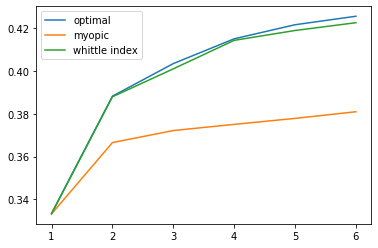

In [25]:
p1 = plt.plot(range(1, 7), optimal_rew, label='optimal')
p2 = plt.plot(range(1, 7), cum_AR_myopic, label = 'myopic')
p3 = plt.plot(range(1, 7), cum_AR_whittle_index, label = 'whittle index')
#plt.legend(handles=[p1, p2, p3], 
#           labels=['optimal', 'myopic', 'whittle index'],
#           loc='best')
plt.legend(loc = 'upper left')
plt.show()

In [39]:
cum_1 = np.array([0.34617878, 0.38755675, 0.40627781, 0.41685498, 0.42820373,
       0.43038558])

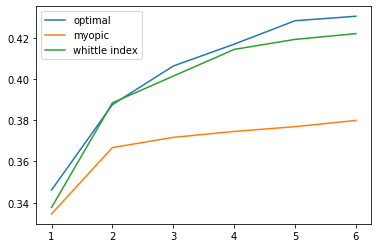

In [40]:
p1 = plt.plot(range(1, 7), cum_1, label='optimal')
p2 = plt.plot(range(1, 7), cum_AR_myopic, label = 'myopic')
p3 = plt.plot(range(1, 7), cum_AR_whittle_index, label = 'whittle index')
#plt.legend(handles=[p1, p2, p3], 
#           labels=['optimal', 'myopic', 'whittle index'],
#           loc='best')
plt.legend(loc = 'upper left')
plt.show()

In [45]:
import numpy.linalg as nplg

In [48]:
stat_dist = transition_matrics[:, 0, 1]/(transition_matrics[:, 0, 1] + transition_matrics[:, 1, 0])
stat_dist = np.array([1 - stat_dist, stat_dist]).T
stat_dist[:,1]

array([0.66666667, 0.5       , 0.33333333, 0.52941176, 0.57142857,
       0.4       , 0.5       ])

In [47]:
J, A = nplg.eig(transition_matrics)
A_inv = nplg.inv(A)

In [53]:
for n in range(100000):
    user = Whittle_Index_Three_State(arm_num, state_num, initial_dist, stat_dist, transition_matrics, active_num, reward_set, 6)
    user.User_process(0.999999999, [True, A, J, A_inv])
    AR_100000[n] = user.AR 

In [55]:
cum_AR_whittle_index = (AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000
cum_AR_whittle_index

array([0.70012   , 0.56491982, 0.49760631, 0.48126028, 0.46861304,
       0.46156793])

In [36]:
cum_AR_whittle_index = (AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000
cum_AR_whittle_index

array([0.70154   , 0.52445146, 0.49524507, 0.47884107, 0.47389213,
       0.46756938])

In [37]:
for n in range(100000):
    user = Myopic_User(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, 6)
    user.User_process()
    #print(user.action)
    AR_100000[n] = user.AR

In [38]:
cum_AR_myopic = (AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000
(AR_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/100000

array([0.70132   , 0.57209797, 0.51115246, 0.48455408, 0.46910742,
       0.4585833 ])

In [32]:
for t in range(1, time + 1):
    a, b = dis_reward(initial_dist[:, 1], 1, reward_set[:, 1], t, arm_num, transition_matrics[:, 0, 1], transition_matrics[:, 1, 1], 1)
    print(b/t)

0.7
0.5715399999999999
0.510908288
0.48598694960000005
0.47441705284480007
0.46970628625802674


In [ ]:
array([0.70012   , 0.56491982, 0.49760631, 0.48126028, 0.46861304,
       0.46156793])